# Curriculum Temperature Knowledge Distillation (CTKD) — CIFAR-100

---

### Method Summary

This notebook extends the original **CTKD** (Li et al., ECCV 2022) with two modifications:

1. **Instance-conditioned temperature** — instead of a single global $\\tau$, each sample in the batch
   receives its own temperature $\\tau_i$ produced by a lightweight MLP that reads the student's
   logits. This allows harder / easier samples to receive different distillation temperatures.

2. **MLP temperature network** — replaces the scalar $\\phi$ parameter with a 3-layer MLP
   (`logits → 256 → 128 → 1`) whose output is sigmoid-scaled to $[\\tau_{min}, \\tau_{max}]$.
   The GRL is applied on the MLP's output before the sigmoid so the network maximises the KD
   loss adversarially while the student minimises it.

$$\\mathcal{L} = (1 - \\alpha) \\cdot \\mathcal{L}_{CE}^{\\text{smooth}}(z^S, y) + \\alpha \\cdot \\mathbb{E}_i[\\tau_i^2 \\cdot \\text{KL}(p^T_{\\tau_i} \\| p^S_{\\tau_i})]$$

The GRL schedule remains the same sigmoid anneal from the original paper.

---
**Teacher:** ResNet-18 loaded from `checkpoints/best_teacher.pth`  
**Student:** MobileNetV2 trained from scratch (no pretrained weights)  
**Training regime:** SGD + Nesterov, CosineAnnealingLR T_max=125 eta_min=1e-4, lr=0.05, wd=1e-4  
**Checkpoint:** `b5_mobilenetv2_ctkd_mlp_instance_cifar100.pth`


## 1. Environment Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_AMP = torch.cuda.is_available()

print(f'Device      : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
print(f'PyTorch     : {torch.__version__}')
print(f'Mixed prec. : {USE_AMP}')


Device      : cuda
GPU         : Tesla T4
PyTorch     : 2.10.0+cu128
Mixed prec. : True


In [2]:
import zipfile, os
from pathlib import Path

# ── Where Kaggle extracted your dataset ───────────────────────────────────
EXTRACTED_DIR = Path('/kaggle/input/datasets/subhankashif/teache/best_teacher')

# ── Re-pack the folder into a zip in /kaggle/working ──────────────────────
REPACKED_ZIP = Path('/kaggle/working/best_teacher_repacked.zip')

if not REPACKED_ZIP.exists():
    print(f'Re-packing {EXTRACTED_DIR} → {REPACKED_ZIP} ...')
    with zipfile.ZipFile(REPACKED_ZIP, 'w') as zf:
        for file in sorted(EXTRACTED_DIR.rglob('*')):
            if file.is_file():
                # arcname must recreate the  best_teacher/...  structure
                arcname = 'best_teacher/' + str(file.relative_to(EXTRACTED_DIR))
                zf.write(file, arcname)
    print(f'Done. Size: {REPACKED_ZIP.stat().st_size / 1e6:.1f} MB')
else:
    print(f'Repacked zip already exists: {REPACKED_ZIP}')

# ── Now torch.load works normally ─────────────────────────────────────────
raw = torch.load(str(REPACKED_ZIP), map_location=DEVICE, weights_only=False)
print(type(raw), raw.keys() if isinstance(raw, dict) else '')

Re-packing /kaggle/input/datasets/subhankashif/teache/best_teacher → /kaggle/working/best_teacher_repacked.zip ...
Done. Size: 44.9 MB
<class 'collections.OrderedDict'> odict_keys(['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.num_batches_tracked', 'layer1.1.conv2.weight', 'layer1.1.bn2.weight', 'layer1.1.bn2.bias', 'layer1.1.bn2.running_mean', 'layer1.1.bn2.running_var', 'layer1.1.bn2.num_batches_tracked', 'layer2.0.conv1.weight', 'layer2.0.bn1.weight', 'layer2.0.bn1.b

## 2. Configuration

In [3]:
DATA_DIR = Path('./data')
CKPT_DIR = Path('./checkpoints')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

TEACHER_CKPT = REPACKED_ZIP

NUM_CLASSES = 100
CIFAR_MEAN  = (0.5071, 0.4867, 0.4408)
CIFAR_STD   = (0.2675, 0.2565, 0.2761)

# -- Training schedule (matches retrained baseline notebook) ------------------
EPOCHS     = 125
BATCH_SIZE = 128

LR           = 0.05    # CHANGED: was 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 1e-4    # CHANGED: was 5e-4
# Scheduler: CosineAnnealingLR T_max=125 eta_min=1e-4  (was MultiStepLR)
# LR_MILESTONES / LR_GAMMA removed — no longer used

# -- CTKD hyperparameters -----------------------------------------------------
ALPHA          = 0.7    # CHANGED: was 0.9  (matches retrained B3 KD alpha)
TAU_MIN        = 1.0    # lower bound for learnable temperature
TAU_MAX        = 10.0   # upper bound for learnable temperature
LR_TEMP        = 1e-3   # separate learning rate for temperature parameter
GRL_LAMBDA_MAX = 1.0    # maximum GRL reversal coefficient
# CE loss: label_smoothing=0.1 -- see Loss section

print('Configuration loaded.')
print(f'  Epochs         : {EPOCHS}')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  LR             : {LR}  (was 0.1)')
print(f'  Weight decay   : {WEIGHT_DECAY}  (was 5e-4)')
print(f'  Scheduler      : CosineAnnealingLR T_max={EPOCHS} eta_min=1e-4  (was MultiStepLR)')
print(f'  alpha (KD)     : {ALPHA}  (was 0.9)')
print(f'  tau range      : [{TAU_MIN}, {TAU_MAX}]')
print(f'  LR_TEMP        : {LR_TEMP}')
print(f'  GRL lambda max : {GRL_LAMBDA_MAX}')
print(f'  CE loss        : label_smoothing=0.1  (was 0.0)')


Configuration loaded.
  Epochs         : 125
  Batch size     : 128
  LR             : 0.05  (was 0.1)
  Weight decay   : 0.0001  (was 5e-4)
  Scheduler      : CosineAnnealingLR T_max=125 eta_min=1e-4  (was MultiStepLR)
  alpha (KD)     : 0.7  (was 0.9)
  tau range      : [1.0, 10.0]
  LR_TEMP        : 0.001
  GRL lambda max : 1.0
  CE loss        : label_smoothing=0.1  (was 0.0)


## 3. Data Pipeline — CIFAR-100

In [4]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    transforms.RandomErasing(p=0.25),   # matches retrained baseline notebook
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_ds = datasets.CIFAR100(root=DATA_DIR, train=True,  download=True, transform=train_transform)
test_ds  = datasets.CIFAR100(root=DATA_DIR, train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256,        shuffle=False, num_workers=2, pin_memory=True)

print(f'Train : {len(train_ds):,} samples  ({len(train_loader)} batches)')
print(f'Test  : {len(test_ds):,} samples  ({len(test_loader)} batches)')


100%|██████████| 169M/169M [00:02<00:00, 74.1MB/s] 


Train : 50,000 samples  (391 batches)
Test  : 10,000 samples  (40 batches)


## 4. Model Definitions

### 4.1 Teacher — ResNet-18

Teacher-loading logic identical to the DKD+CTKD notebook.

In [5]:
def build_resnet18_cifar(num_classes):
    m = models.resnet18(weights=None)
    m.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc      = nn.Linear(512, num_classes)
    return m


def build_resnet18_standard(num_classes):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(512, num_classes)
    return m


def load_teacher(ckpt_path, num_classes, device):
    """
    Robust teacher loader (identical to DKD+CTKD notebook).
    Handles {'state_dict': ..., ...} and raw state_dict formats.
    Strips 'module.' prefix from DataParallel saves.
    Auto-detects conv1 architecture from checkpoint weights.
    """
    raw   = torch.load(ckpt_path, map_location=device)
    state = raw.get('state_dict', raw) if isinstance(raw, dict) else raw
    state = {k.replace('module.', ''): v for k, v in state.items()}

    conv1_kernel = state['conv1.weight'].shape[2]

    if conv1_kernel == 3:
        print(f'  Detected conv1 kernel=3x3 -> building CIFAR-adapted ResNet-18')
        model = build_resnet18_cifar(num_classes).to(device)
    else:
        print(f'  Detected conv1 kernel=7x7 -> building standard ResNet-18')
        model = build_resnet18_standard(num_classes).to(device)

    missing, unexpected = model.load_state_dict(state, strict=False)
    if missing:
        print(f'  [WARN] Missing keys   : {missing}')
    if unexpected:
        print(f'  [WARN] Unexpected keys: {unexpected}')

    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    reported = raw.get('top1', raw.get('val_top1', 'N/A')) if isinstance(raw, dict) else 'N/A'
    print(f'Teacher loaded from  : {ckpt_path}')
    print(f'  conv1 kernel       : {conv1_kernel}x{conv1_kernel}')
    print(f'  Checkpoint top-1   : {reported}')
    return model


teacher = load_teacher(TEACHER_CKPT, NUM_CLASSES, DEVICE)
print(f'  Trainable params   : {sum(p.numel() for p in teacher.parameters() if p.requires_grad)}')
print('  Teacher is frozen -- will never update during training.')


  Detected conv1 kernel=3x3 -> building CIFAR-adapted ResNet-18
Teacher loaded from  : /kaggle/working/best_teacher_repacked.zip
  conv1 kernel       : 3x3
  Checkpoint top-1   : N/A
  Trainable params   : 0
  Teacher is frozen -- will never update during training.


### 4.2 Student — MobileNetV2 (from scratch)

In [6]:
def build_mobilenetv2_cifar(num_classes):
    """MobileNetV2 for 32x32 CIFAR, trained from scratch."""
    m = models.mobilenet_v2(weights=None)
    m.features[0][0] = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
    m.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(m.last_channel, num_classes),
    )
    return m


student = build_mobilenetv2_cifar(NUM_CLASSES).to(DEVICE)

total_p     = sum(p.numel() for p in student.parameters()) / 1e6
trainable_p = sum(p.numel() for p in student.parameters() if p.requires_grad) / 1e6
print(f'Student : MobileNetV2  |  {total_p:.2f}M total  |  {trainable_p:.2f}M trainable')
print('Weights : randomly initialised (no pretrained backbone) -- matches baseline methodology.')


Student : MobileNetV2  |  2.35M total  |  2.35M trainable
Weights : randomly initialised (no pretrained backbone) -- matches baseline methodology.


## 5. Gradient Reversal Layer (GRL)

The GRL is the adversarial mechanism in CTKD.

- **Forward:** identity — data passes through unchanged.
- **Backward:** gradients are multiplied by $-\lambda$.

When placed between the model features and the temperature parameter, the student minimises
the loss while the temperature maximises it, creating a progressive difficulty curriculum.

$\lambda$ is annealed from 0 to `GRL_LAMBDA_MAX` via the sigmoid schedule from the CTKD paper:

$$\lambda(p) = \frac{2 \cdot \lambda_{max}}{1 + e^{-10p}} - \lambda_{max}, \quad p = \frac{\text{epoch}}{\text{total\_epochs}}$$


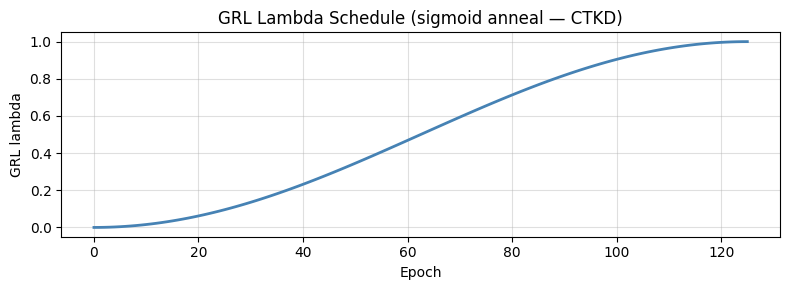

lambda at epoch   0 : 0.0000
lambda at epoch   31 : 0.1442
lambda at epoch   62 : 0.4937
lambda at epoch 125 : 1.0000


In [15]:
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, grl_lambda):
        ctx.save_for_backward(torch.tensor(grl_lambda))
        return x.clone()

    @staticmethod
    def backward(ctx, grad_output):
        grl_lambda, = ctx.saved_tensors
        return -grl_lambda.item() * grad_output, None


def grad_reverse(x, grl_lambda):
    return GradientReversalFunction.apply(x, grl_lambda)


def compute_grl_lambda(epoch, total_epochs, lambda_max=GRL_LAMBDA_MAX):
    """Sigmoid-annealed GRL schedule from CTKD (Li et al., ECCV 2022)."""
    progress = min(epoch, total_epochs) / total_epochs

    lam = 0.0 + 0.5 * (lambda_max - 0.0) * (
        1 - np.cos(np.pi * progress)
    )

    return lam


ep_range = np.arange(0, EPOCHS + 1)
lambdas  = [compute_grl_lambda(e, EPOCHS) for e in ep_range]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ep_range, lambdas, color='steelblue', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('GRL lambda')
ax.set_title('GRL Lambda Schedule (sigmoid anneal — CTKD)')
ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print(f'lambda at epoch   0 : {compute_grl_lambda(0,          EPOCHS):.4f}')
print(f'lambda at epoch  {EPOCHS//4:3d} : {compute_grl_lambda(EPOCHS//4,  EPOCHS):.4f}')
print(f'lambda at epoch  {EPOCHS//2:3d} : {compute_grl_lambda(EPOCHS//2,  EPOCHS):.4f}')
print(f'lambda at epoch {EPOCHS:3d} : {compute_grl_lambda(EPOCHS,     EPOCHS):.4f}')


## 6. Instance-Conditioned Temperature MLP

Instead of a single global scalar $\\tau$, a lightweight 3-layer MLP maps each sample's
student logits to a **per-instance** temperature:

$$\\tau_i = \\tau_{min} + (\\tau_{max} - \\tau_{min}) \\cdot \\sigma\\bigl(\\text{MLP}(z^S_i)\\bigr)$$

**MLP architecture:** `C → 256 → 128 → 1` (C = num_classes = 100)  
**Activation:** ReLU in hidden layers, no activation on output (sigmoid applied separately for range constraint)  
**GRL:** applied to the raw MLP output so the network is trained adversarially.

The per-instance temperature is detached (as a scalar) from the student's main computation graph;
only the temperature MLP's parameters receive the reversed gradient.


In [8]:
class TemperatureModule(nn.Module):
    """
    Instance-conditioned temperature MLP for CTKD.

    Architecture:  logits (C,) -> Linear(C,256) -> ReLU -> Linear(256,128) -> ReLU -> Linear(128,1)
    Output is sigmoid-scaled to [tau_min, tau_max] per sample.
    The GRL is applied to the raw MLP output so the network maximises the KD loss
    while the student minimises it.

    Forward input : s_logits (B, C)  -- student logits (detached from student graph)
                    grl_lambda       -- current GRL coefficient
    Forward output: tau (B,)         -- per-instance temperature
    """

    def __init__(self, num_classes=NUM_CLASSES, tau_min=TAU_MIN, tau_max=TAU_MAX):
        super().__init__()
        self.tau_min = tau_min
        self.tau_max = tau_max

        self.mlp = nn.Sequential(
            nn.Linear(num_classes, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 1),
        )

        # Initialise last layer so that sigmoid output ≈ (4.0 - tau_min)/(tau_max - tau_min)
        # i.e. starting temperature ≈ 4.0 (classical KD convention)
        init_ratio = (4.0 - tau_min) / (tau_max - tau_min)
        init_bias  = float(np.log(init_ratio / (1.0 - init_ratio)))
        nn.init.zeros_(self.mlp[-1].weight)
        nn.init.constant_(self.mlp[-1].bias, init_bias)

    def _constrain(self, x):
        """Sigmoid-scale raw output to [tau_min, tau_max]. x: (B, 1)"""
        return self.tau_min + (self.tau_max - self.tau_min) * torch.sigmoid(x)

    @torch.no_grad()
    def tau_mean(self, s_logits):
        """Return mean temperature over a batch, no GRL (for logging)."""
        raw = self.mlp(s_logits.detach())          # (B, 1)
        return self._constrain(raw).mean().item()

    def forward(self, s_logits, grl_lambda):
        """
        s_logits : (B, C)  student logits — detached from student backward graph
        Returns  : tau (B, 1)  per-instance temperature (GRL applied)
        """
        raw     = self.mlp(s_logits.detach())               # (B, 1)
        raw_grl = grad_reverse(raw, grl_lambda)    # GRL on the MLP output
        return self._constrain(raw_grl)            # (B, 1)


temp_module = TemperatureModule(NUM_CLASSES, TAU_MIN, TAU_MAX).to(DEVICE)

total_temp_p = sum(p.numel() for p in temp_module.parameters())
print('TemperatureModule (MLP, instance-conditioned) initialised.')
print(f'  Architecture     : {NUM_CLASSES} -> 256 -> 128 -> 1')
print(f'  Trainable params : {total_temp_p:,}')
print(f'  tau range        : [{TAU_MIN}, {TAU_MAX}]')
# Check init temperature on a dummy batch
_dummy = torch.zeros(4, NUM_CLASSES).to(DEVICE)
_tau_init = temp_module.tau_mean(_dummy)
print(f'  tau at init (zero logits) : {_tau_init:.4f}  (target ≈ 4.0)')


TemperatureModule (MLP, instance-conditioned) initialised.
  Architecture     : 100 -> 256 -> 128 -> 1
  Trainable params : 58,881
  tau range        : [1.0, 10.0]
  tau at init (zero logits) : 4.0000  (target ≈ 4.0)


## 7. CTKD Loss (Instance Temperature)

The KD loss is computed per-sample using each sample's own $\\tau_i$,
then averaged over the batch.

$$\\mathcal{L}_{KD} = \\frac{1}{B}\\sum_{i=1}^{B} \\tau_i^2 \\cdot \\text{KL}\\bigl(p^T_{\\tau_i} \\| p^S_{\\tau_i}\\bigr)$$

Because $\\tau_i$ is a vector `(B,)`, softmax is applied row-wise with each row's own temperature.


In [9]:
class CTKDLoss(nn.Module):
    """
    CTKD loss with **per-instance** temperature.

    CE is computed via criterion_ce (label_smoothing=0.1) passed in from the caller.

    Forward:
        s_logits    : (B, C) student logits
        t_logits    : (B, C) teacher logits  (no_grad expected from caller)
        labels      : (B,)   integer labels
        tau         : (B, 1) per-instance temperature tensor (with GRL applied)
        criterion_ce: nn.CrossEntropyLoss(label_smoothing=0.1) -- passed in

    Returns:
        total_loss, kd_loss (detached scalar), ce_loss (detached scalar)
    """

    def __init__(self, alpha=ALPHA):
        super().__init__()
        self.alpha = alpha

    def forward(self, s_logits, t_logits, labels, tau, criterion_ce):
        # CE loss (label-smoothed)
        ce_loss = criterion_ce(s_logits, labels)

        # Per-instance softmax: tau is (B, 1), logits are (B, C)
        t_soft = F.softmax(t_logits.detach() / tau, dim=1)  # 🔥 FIX

        s_log   = F.log_softmax(s_logits / tau, dim=1)      # (B, C)

        # KL per sample then average; tau^2 scaling per sample
        kl_per = F.kl_div(s_log, t_soft, reduction='none').sum(dim=1)  # 🔥 FIX
    
        tau_sq  = (tau ** 2).squeeze(1)                          # (B,)
        kd_loss = (tau_sq * kl_per).mean()

        total = self.alpha * kd_loss + (1.0 - self.alpha) * ce_loss
        return total, kd_loss.detach(), ce_loss.detach()


# Label-smoothed CE
criterion_ce = nn.CrossEntropyLoss(label_smoothing=0.0)
criterion     = CTKDLoss(alpha=ALPHA)

print('CTKDLoss (instance temperature) instantiated.')
print(f'  alpha (KD weight) : {criterion.alpha}')
print(f'  CE (label smooth) : label_smoothing=0.0')
print('  tau shape in forward: (B, 1)  -- per-instance')


CTKDLoss (instance temperature) instantiated.
  alpha (KD weight) : 0.7
  CE (label smooth) : label_smoothing=0.0
  tau shape in forward: (B, 1)  -- per-instance


## 8. Optimiser and Scheduler

SGD + Nesterov, CosineAnnealingLR — identical to the retrained baseline notebook.
Temperature parameter in a separate param group with its own LR so it is unaffected by
the student's cosine decay.


In [10]:
student_params = list(student.parameters())

optimizer = torch.optim.SGD([
    {'params': student_params,           'lr': LR},
    {'params': temp_module.parameters(), 'lr': LR_TEMP},
], momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-4
)

total_temp_p = sum(p.numel() for p in temp_module.parameters())
print('Optimiser and scheduler configured.')
print(f'  Optimiser  : SGD (Nesterov)  student lr={LR}  temp MLP lr={LR_TEMP}')
print(f'  Scheduler  : CosineAnnealingLR  T_max={EPOCHS}  eta_min=1e-4')
print(f'  WD         : {WEIGHT_DECAY}')
print(f'  Temp MLP params : {total_temp_p:,}  (not decayed by scheduler)')


Optimiser and scheduler configured.
  Optimiser  : SGD (Nesterov)  student lr=0.05  temp MLP lr=0.001
  Scheduler  : CosineAnnealingLR  T_max=125  eta_min=1e-4
  WD         : 0.0001
  Temp MLP params : 58,881  (not decayed by scheduler)


## 9. Evaluation Utility

In [11]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    top1_c = top5_c = total = 0
    for imgs, labels in tqdm(loader, desc='Eval', leave=False, dynamic_ncols=True):
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        top1_c += (logits.argmax(1) == labels).sum().item()
        top5_c += (logits.topk(5, dim=1).indices == labels.unsqueeze(1)).any(1).sum().item()
        total  += labels.size(0)
    return 100.0 * top1_c / total, 100.0 * top5_c / total

print('evaluate() ready -- returns (top1 %, top5 %).')


evaluate() ready -- returns (top1 %, top5 %).


## 10. Training Loop

In [12]:
def train_one_epoch(student, teacher, temp_module, criterion, criterion_ce,
                    optimizer, loader, grl_lambda, device, epoch, total_epochs):
    """One epoch of CTKD training with instance-conditioned temperature MLP."""
    student.train()
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad_(False)
    temp_module.train()

    sums = dict(total=0., kd=0., ce=0., tau_sum=0., correct=0, n=0)
    pbar = tqdm(loader, desc=f'Ep {epoch:3d}/{total_epochs}', leave=False, dynamic_ncols=True)

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        B = imgs.size(0)

        with torch.no_grad():
            t_logits = teacher(imgs)

        optimizer.zero_grad()
        s_logits = student(imgs)                       # (B, C)

        # GRL disabled for first 5 epochs for stable warmup
        effective_lambda = grl_lambda if epoch > 5 else 0.0

        # Instance temperature: MLP sees detached student logits so student
        # gradients do NOT flow back through the MLP; only MLP params update.
        tau = temp_module(s_logits.detach(), effective_lambda)  # (B, 1)

        total_loss, kd_l, ce_l = criterion(s_logits, t_logits, labels, tau, criterion_ce)
        total_loss.backward()
        optimizer.step()

        tau_mean_batch = tau.detach().mean().item()

        sums['total']   += total_loss.item() * B
        sums['kd']      += kd_l.item()       * B
        sums['ce']      += ce_l.item()        * B
        sums['tau_sum'] += tau_mean_batch     * B
        sums['correct'] += (s_logits.argmax(1) == labels).sum().item()
        sums['n']       += B

        pbar.set_postfix(loss=f'{total_loss.item():.3f}', tau=f'{tau_mean_batch:.2f}')

    n = sums['n']
    return {
        'total_loss' : sums['total']   / n,
        'kd_loss'    : sums['kd']      / n,
        'ce_loss'    : sums['ce']      / n,
        'train_acc'  : 100.0 * sums['correct'] / n,
        'tau'        : sums['tau_sum'] / n,   # mean tau over epoch
        'grl_lambda' : grl_lambda,
    }

print('train_one_epoch() defined (instance-conditioned temperature MLP).')


train_one_epoch() defined (instance-conditioned temperature MLP).


## 11. Training Run

In [16]:
history = {
    'epoch': [],
    'total_loss': [],
    'kd_loss': [],
    'ce_loss': [],
    'train_acc': [],
    'test_top1': [],
    'test_top5': [],
    'tau': [],
    'grl_lambda': [],
}

best_top1  = 0.0
best_epoch = 0

print('Starting CTKD training...')
print(f'  Epochs        : {EPOCHS}')
print(f'  alpha         : {ALPHA}')
print(f'  tau range     : [{TAU_MIN}, {TAU_MAX}] (per-instance MLP)')
print(f'  CE smoothing  : 0.1')
print('-' * 80)


for epoch in range(1, EPOCHS + 1):

    # --- GRL lambda schedule ---
    grl_lambda = compute_grl_lambda(epoch, EPOCHS, GRL_LAMBDA_MAX)

    # --- Train ---
    metrics = train_one_epoch(
        student,
        teacher,
        temp_module,
        criterion,
        criterion_ce,
        optimizer,
        train_loader,
        grl_lambda,
        DEVICE,
        epoch,
        EPOCHS
    )

    # --- Evaluate ---
    top1, top5 = evaluate(student, test_loader, DEVICE)

    # --- LR scheduler ---
    scheduler.step()

    # --- Store history ---
    history['epoch'].append(epoch)
    history['total_loss'].append(metrics['total_loss'])
    history['kd_loss'].append(metrics['kd_loss'])
    history['ce_loss'].append(metrics['ce_loss'])
    history['train_acc'].append(metrics['train_acc'])
    history['test_top1'].append(top1)
    history['test_top5'].append(top5)
    history['tau'].append(metrics['tau'])
    history['grl_lambda'].append(grl_lambda)

    # --- Save best model ---
    if top1 > best_top1:
        best_top1  = top1
        best_epoch = epoch

        torch.save({
            'state_dict': student.state_dict(),
            'temp_state': temp_module.state_dict(),
            'epoch': epoch,
            'top1': top1,
            'top5': top5,
            'tau': metrics['tau'],
            'alpha': ALPHA,
            'lr': LR,
            'wd': WEIGHT_DECAY,
            'label_smoothing': 0.1,
            'scheduler': 'CosineAnnealingLR',
        }, CKPT_DIR / 'mobilenetv2_ctkd_instance_best.pth')

    # --- Logging ---
    if epoch < 10 or epoch % 10 == 0 or epoch == EPOCHS:
        current_lr = scheduler.get_last_lr()[0]

        print(
            f'Ep {epoch:3d}/{EPOCHS} | '
            f'loss {metrics["total_loss"]:.3f} '
            f'(kd {metrics["kd_loss"]:.3f} | ce {metrics["ce_loss"]:.3f}) | '
            f'train {metrics["train_acc"]:.2f}% | '
            f'test top1 {top1:.2f}% top5 {top5:.2f}% | '
            f'tau {metrics["tau"]:.2f} | '
            f'λ {grl_lambda:.3f} | '
            f'lr {current_lr:.5f}'
            + (' [*]' if top1 == best_top1 else '')
        )


print('-' * 80)
print('Training complete.')
print(f'  Best test Top-1 : {best_top1:.2f}% (epoch {best_epoch})')
print(f'  Checkpoint      : mobilenetv2_ctkd_instance_best.pth')
print(f'  Initial tau     : ~4.00 -> Final: {history["tau"][-1]:.3f}')


# --- Save history ---
import json

with open(CKPT_DIR / 'ctkd_training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print('Training history saved.')

Starting CTKD training...
  Epochs        : 125
  alpha         : 0.7
  tau range     : [1.0, 10.0] (per-instance MLP)
  CE smoothing  : 0.1
--------------------------------------------------------------------------------


Ep   1/125 | loss 7.627 (kd 9.234 | ce 3.877) | train 14.08% | test top1 20.32% top5 49.75% | tau 4.00 | λ 0.000 | lr 0.04999 [*]


Ep   2/125 | loss 6.865 (kd 8.271 | ce 3.585) | train 19.76% | test top1 24.89% top5 55.41% | tau 4.00 | λ 0.001 | lr 0.04997 [*]


Ep   3/125 | loss 6.241 (kd 7.485 | ce 3.337) | train 24.96% | test top1 29.70% top5 60.98% | tau 4.00 | λ 0.001 | lr 0.04993 [*]


Ep   4/125 | loss 5.688 (kd 6.787 | ce 3.123) | train 28.98% | test top1 35.68% top5 68.62% | tau 4.00 | λ 0.003 | lr 0.04987 [*]


...

Ep  90/125 | loss 1.070 (kd 1.323 | ce 0.478) | train 86.36% | test top1 72.04% top5 92.21% | tau 3.32 | λ 0.819 | lr 0.00915


Ep 100/125 | loss 0.976 (kd 1.211 | ce 0.429) | train 88.12% | test top1 72.55% top5 92.60% | tau 3.36 | λ 0.905 | lr 0.00487


Ep 110/125 | loss 0.909 (kd 1.131 | ce 0.393) | train 89.27% | test top1 72.50% top5 92.75% | tau 3.40 | λ 0.965 | lr 0.00185


Ep 120/125 | loss 0.889 (kd 1.106 | ce 0.382) | train 89.54% | test top1 72.82% top5 92.85% | tau 3.40 | λ 0.996 | lr 0.00030


Ep 125/125 | loss 0.891 (kd 1.107 | ce 0.386) | train 89.70% | test top1 72.86% top5 92.83% | tau 3.41 | λ 1.000 | lr 0.00010
--------------------------------------------------------------------------------
Training complete.
  Best test Top-1 : 72.87% (epoch 115)
  Checkpoint      : mobilenetv2_ctkd_instance_best.pth
  Initial tau     : ~4.00 -> Final: 3.407
Training history saved.


## 12. Visualisations

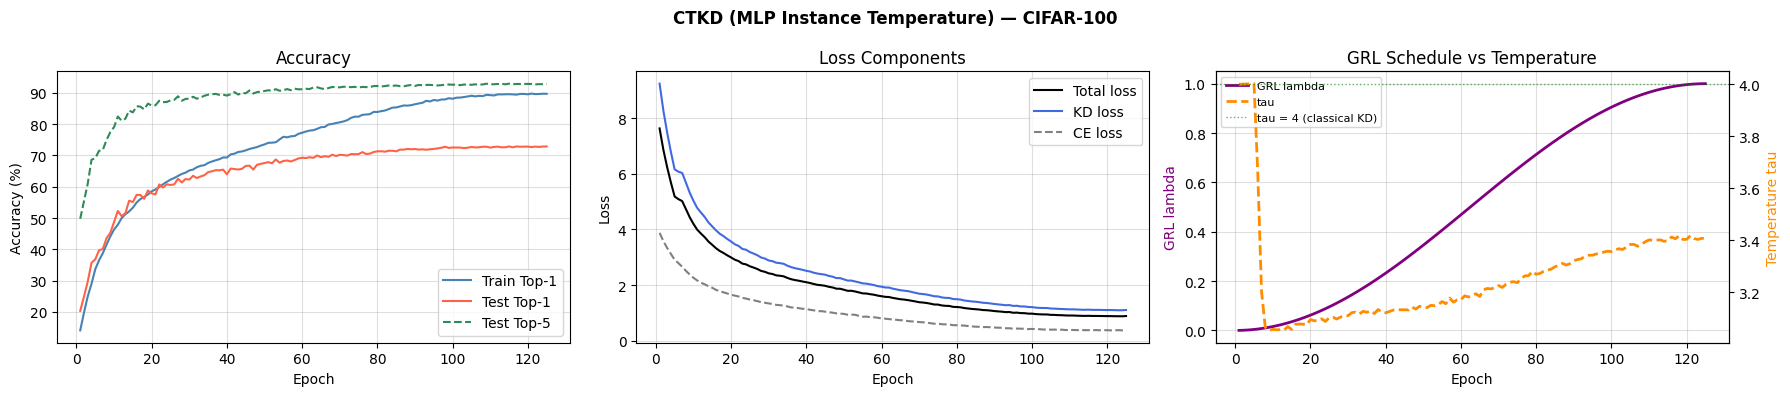

Temperature curriculum: init ~4.00 -> final 3.407


In [17]:
ep = history['epoch']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('CTKD (MLP Instance Temperature) — CIFAR-100', fontweight='bold')


# ─────────────────────────────────────────────────────────────
# 1. Accuracy Plot
# ─────────────────────────────────────────────────────────────
axes[0].plot(ep, history['train_acc'], label='Train Top-1', color='steelblue')
axes[0].plot(ep, history['test_top1'], label='Test Top-1', color='tomato')
axes[0].plot(ep, history['test_top5'], label='Test Top-5', color='seagreen', linestyle='--')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.4)


# ─────────────────────────────────────────────────────────────
# 2. Loss Plot
# ─────────────────────────────────────────────────────────────
axes[1].plot(ep, history['total_loss'], label='Total loss', color='black')
axes[1].plot(ep, history['kd_loss'], label='KD loss', color='royalblue')
axes[1].plot(ep, history['ce_loss'], label='CE loss', color='gray', linestyle='--')

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss Components')
axes[1].legend()
axes[1].grid(True, alpha=0.4)


# ─────────────────────────────────────────────────────────────
# 3. GRL λ vs Temperature τ
# ─────────────────────────────────────────────────────────────
ax3 = axes[2]
ax3b = ax3.twinx()

# GRL lambda
ax3.plot(ep, history['grl_lambda'],
         color='purple', linewidth=2, label='GRL lambda')

# Temperature
ax3b.plot(ep, history['tau'],
          color='darkorange', linewidth=2, linestyle='--', label='tau')

# Reference line (classical KD)
ax3b.axhline(4.0,
             color='green', linestyle=':', linewidth=1, alpha=0.6,
             label='tau = 4 (classical KD)')


ax3.set_xlabel('Epoch')
ax3.set_ylabel('GRL lambda', color='purple')
ax3b.set_ylabel('Temperature tau', color='darkorange')

ax3.set_title('GRL Schedule vs Temperature')

# Merge legends
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

ax3.grid(True, alpha=0.4)


# ─────────────────────────────────────────────────────────────
plt.tight_layout()
plt.show()

print(f'Temperature curriculum: init ~4.00 -> final {history["tau"][-1]:.3f}')

## 13. Results Summary

In [18]:
baseline_results = {
    'B1 ResNet-18 Teacher': {
        'top1': None,
        'note': 'Teacher ceiling'
    },
    'B2 MobileNetV2 Vanilla': {
        'top1': None,
        'note': 'Student w/o KD (retrained)'
    },
    'B3 MobileNetV2 + Classical KD': {
        'top1': None,
        'note': 'Primary baseline (retrained)'
    },
    'B4 DKD (cosine)': {
        'top1': None,
        'note': 'DKD fixed tau, cosine regime'
    },
}

# Load baseline checkpoints
for ckpt_file, key in [
    ('b1_resnet18_teacher_cifar100.pth', 'B1 ResNet-18 Teacher'),
    ('b2_mobilenetv2_vanilla_cifar100.pth', 'B2 MobileNetV2 Vanilla'),
    ('b3_mobilenetv2_kd_cifar100.pth', 'B3 MobileNetV2 + Classical KD'),
    ('b4_mobilenetv2_dkd_cifar100_cosine.pth', 'B4 DKD (cosine)'),
]:
    path = CKPT_DIR / ckpt_file

    if path.exists():
        ckpt = torch.load(path, map_location='cpu')

        t1 = ckpt.get('top1', ckpt.get('val_top1', None))
        if t1 is not None:
            baseline_results[key]['top1'] = round(t1, 2)

# Build table
rows = [
    {
        'Model': k,
        'Top-1 (%)': v['top1'],
        'Note': v['note']
    }
    for k, v in baseline_results.items()
]

# Add your model (B5)
rows.append({
    'Model': 'B5 CTKD — MLP instance tau, cosine (ours)',
    'Top-1 (%)': round(best_top1, 2),
    'Note': (
        f'Best epoch {best_epoch} | '
        f'final tau={history["tau"][-1]:.2f} | '
        f'alpha={ALPHA} | label_smoothing=0.1'
    )
})

df = pd.DataFrame(rows)

print('=' * 72)
print('CIFAR-100 RESULTS — CTKD (LEARNABLE TEMPERATURE, COSINE REGIME)')
print('=' * 72)
print(df.to_string(index=False))
print('=' * 72)

# Compare vs classical KD (B3)
b3_top1 = baseline_results['B3 MobileNetV2 + Classical KD']['top1']

if b3_top1 is not None:
    print(
        f'\nGain vs classical KD (B5 - B3): '
        f'{best_top1 - b3_top1:+.2f}%'
    )

# Save summary
import json as _json

with open(CKPT_DIR / 'ctkd_results_summary.json', 'w') as f:
    _json.dump({
        'baseline_results': baseline_results,
        'best': {
            'top1': round(best_top1, 2),
            'epoch': best_epoch,
            'final_tau': history['tau'][-1],
        }
    }, f, indent=2)

print(f'Results saved -> {CKPT_DIR / "ctkd_results_summary.json"}')

CIFAR-100 RESULTS — CTKD (LEARNABLE TEMPERATURE, COSINE REGIME)
                                    Model  Top-1 (%)                                                              Note
                     B1 ResNet-18 Teacher        NaN                                                   Teacher ceiling
                   B2 MobileNetV2 Vanilla        NaN                                        Student w/o KD (retrained)
            B3 MobileNetV2 + Classical KD        NaN                                      Primary baseline (retrained)
                          B4 DKD (cosine)        NaN                                      DKD fixed tau, cosine regime
B5 CTKD — MLP instance tau, cosine (ours)      72.87 Best epoch 115 | final tau=3.41 | alpha=0.7 | label_smoothing=0.1
Results saved -> checkpoints/ctkd_results_summary.json


## 14. Full Training History Table

In [19]:
df_hist = pd.DataFrame({
    'Epoch'      : history['epoch'],
    'Total Loss' : [f'{v:.4f}' for v in history['total_loss']],
    'KD Loss'    : [f'{v:.4f}' for v in history['kd_loss']],
    'CE Loss'    : [f'{v:.4f}' for v in history['ce_loss']],
    'Train Acc'  : [f'{v:.2f}%' for v in history['train_acc']],
    'Test Top-1' : [f'{v:.2f}%' for v in history['test_top1']],
    'Test Top-5' : [f'{v:.2f}%' for v in history['test_top5']],
    'tau'        : [f'{v:.3f}' for v in history['tau']],
    'GRL lambda' : [f'{v:.3f}' for v in history['grl_lambda']],
})
print(df_hist.to_string(index=False))


 Epoch Total Loss KD Loss CE Loss Train Acc Test Top-1 Test Top-5   tau GRL lambda
     1     7.6267  9.2339  3.8768    14.08%     20.32%     49.75% 4.001      0.000
     2     6.8649  8.2707  3.5847    19.76%     24.89%     55.41% 4.001      0.001
     3     6.2405  7.4849  3.3369    24.96%     29.70%     60.98% 4.002      0.001
     4     5.6879  6.7871  3.1231    28.98%     35.68%     68.62% 4.002      0.003
     5     5.1827  6.1578  2.9074    33.63%     36.78%     69.11% 4.003      0.004
     6     5.0885  6.0727  2.7923    36.49%     39.66%     71.48% 3.660      0.006
     7     5.0181  6.0288  2.6597    38.73%     40.09%     71.75% 3.204      0.008
     8     4.7308  5.6812  2.5133    41.50%     43.57%     74.96% 3.065      0.010
     9     4.4410  5.3230  2.3829    44.10%     45.29%     77.45% 3.054      0.013
    10     4.1995  5.0284  2.2653    46.33%     48.74%     79.07% 3.058      0.016
    11     3.9915  4.7729  2.1685    47.85%     52.25%     82.43% 3.056      0.019
    